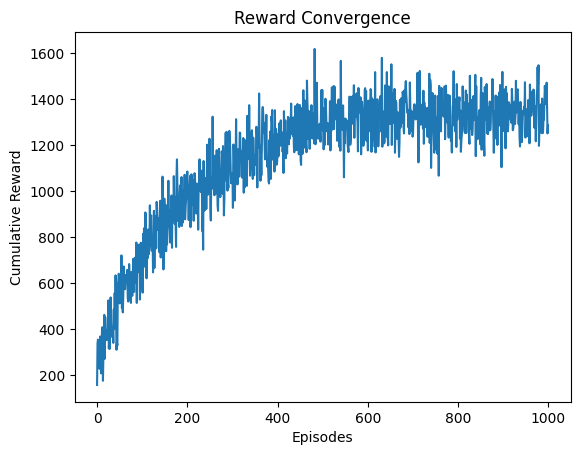

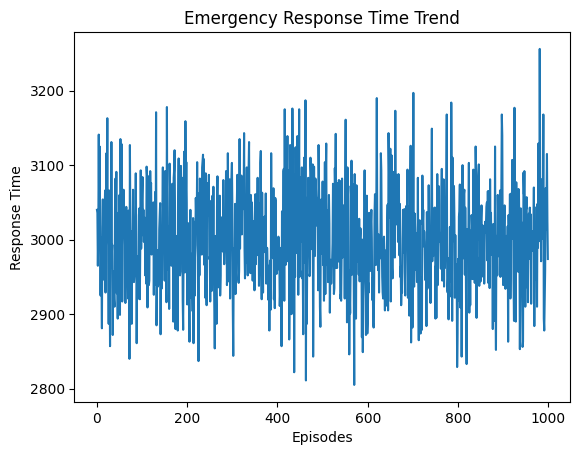

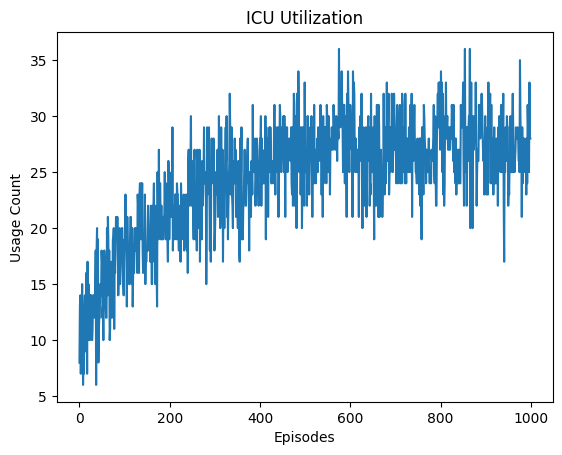


FINAL LEARNED POLICIES


Agent: Ambulance
State 0 -> Action 0
State 1 -> Action 3
State 2 -> Action 1
State 3 -> Action 2
State 4 -> Action 1
State 5 -> Action 3
State 6 -> Action 1
State 7 -> Action 1
State 8 -> Action 1
State 9 -> Action 0
State 10 -> Action 1
State 11 -> Action 3
State 12 -> Action 2
State 13 -> Action 3
State 14 -> Action 3
State 15 -> Action 1
State 16 -> Action 1
State 17 -> Action 1
State 18 -> Action 0
State 19 -> Action 0
State 20 -> Action 0
State 21 -> Action 0
State 22 -> Action 0
State 23 -> Action 0
State 24 -> Action 0
State 25 -> Action 0
State 26 -> Action 0

Agent: Hospital
State 0 -> Action 2
State 1 -> Action 2
State 2 -> Action 3
State 3 -> Action 2
State 4 -> Action 2
State 5 -> Action 3
State 6 -> Action 2
State 7 -> Action 2
State 8 -> Action 3
State 9 -> Action 2
State 10 -> Action 2
State 11 -> Action 3
State 12 -> Action 2
State 13 -> Action 2
State 14 -> Action 3
State 15 -> Action 2
State 16 -> Action 2
State 17 -> Action 3
State 18 -> Act

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt


# PARAMETERS

EPISODES = 1000
MAX_STEPS = 40

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

agents = [
    "Ambulance",
    "Hospital",
    "Traffic",
    "Dispatcher",
    "Triage",
    "ICU_Manager"
]

NUM_ACTIONS = 4

# state = combination of:
# accident severity (0–2)
# traffic (0–2)
# hospital load (0–2)
NUM_STATES = 27  # 3x3x3

# Q tables
Q_tables = {agent: np.zeros((NUM_STATES, NUM_ACTIONS)) for agent in agents}



# STATE GENERATION
def generate_state():
    severity = random.randint(0,2)
    traffic = random.randint(0,2)
    hospital_load = random.randint(0,2)

    # convert to single state number
    return severity*9 + traffic*3 + hospital_load



# REWARD FUNCTION (RESEARCH LEVEL)
def get_reward(agent, state, action):

    severity = state // 9
    traffic = (state % 9) // 3
    hospital_load = state % 3

    reward = 0

    # Ambulance decision
    if agent == "Ambulance":
        if severity == 2 and action == 0:  # fastest route
            reward += 15
        elif traffic == 2 and action == 1:  # alternate route
            reward += 10
        else:
            reward -= 3

    # Hospital bed management
    elif agent == "Hospital":
        if hospital_load == 2 and action == 3:  # redirect patient
            reward += 12
        elif hospital_load < 2 and action == 2:
            reward += 10

    # Traffic control
    elif agent == "Traffic":
        if traffic == 2 and action == 1:
            reward += 8

    # Dispatcher
    elif agent == "Dispatcher":
        if severity == 2 and action == 3:
            reward += 12

    # Triage
    elif agent == "Triage":
        if severity == 2 and action == 2:
            reward += 14

    # ICU
    elif agent == "ICU_Manager":
        if hospital_load < 2 and action == 1:
            reward += 10

    # noise
    reward += random.randint(-2,2)

    return reward



# ENVIRONMENT TRANSITION
def next_state():
    return generate_state()



# METRICS STORAGE
reward_history = []
response_time_history = []
icu_utilization_history = []


# TRAINING LOOP
for episode in range(EPISODES):

    state = generate_state()
    total_reward = 0
    total_response_time = 0
    icu_usage = 0

    for step in range(MAX_STEPS):

        for agent in agents:

            if random.uniform(0,1) < epsilon:
                action = random.randint(0, NUM_ACTIONS-1)
            else:
                action = np.argmax(Q_tables[agent][state])

            reward = get_reward(agent, state, action)
            new_state = next_state()

            # simulate response time
            response_time = random.randint(5,20)
            total_response_time += response_time

            # ICU usage simulation
            if agent == "ICU_Manager" and action == 1:
                icu_usage += 1

            # Q update
            old_value = Q_tables[agent][state][action]
            next_max = np.max(Q_tables[agent][new_state])

            Q_tables[agent][state][action] = old_value + alpha * (
                reward + gamma * next_max - old_value
            )

            state = new_state
            total_reward += reward

    reward_history.append(total_reward)
    response_time_history.append(total_response_time)
    icu_utilization_history.append(icu_usage)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay



# PLOTS (IEEE RESULTS)
plt.figure()
plt.plot(reward_history)
plt.title("Reward Convergence")
plt.xlabel("Episodes")
plt.ylabel("Cumulative Reward")
plt.show()

plt.figure()
plt.plot(response_time_history)
plt.title("Emergency Response Time Trend")
plt.xlabel("Episodes")
plt.ylabel("Response Time")
plt.show()

plt.figure()
plt.plot(icu_utilization_history)
plt.title("ICU Utilization")
plt.xlabel("Episodes")
plt.ylabel("Usage Count")
plt.show()

# FINAL POLICY
print("\nFINAL LEARNED POLICIES\n")

for agent in agents:
    print(f"\nAgent: {agent}")
    for s in range(NUM_STATES):
        best_action = np.argmax(Q_tables[agent][s])
        print(f"State {s} -> Action {best_action}")
